# Gender Pay Gap Analysis: Descriptive Insights Across Job Roles

## Second Notebook: Statistical Analysis

This notebook builds on the insights from the first notebook, which provided a detailed descriptive overview of compensation patterns across job titles, departments, education levels, seniority bands, and gender. The purpose here is to move beyond description and conduct rigorous statistical analyses to validate the observations identified in the exploratory data analysis (EDA).

The overarching research question remains:

**To what extent does gender influence compensation levels across comparable job titles and professional characteristics?**

This notebook will focus on formalizing these observations through appropriate statistical approaches. It will explore patterns in BasePay and Bonus across genders, consider potential interactions with professional characteristics, and provide quantitative evidence to support or refine the insights from the first notebook.

Through these steps, the notebook aims to provide a **robust, evidence-based assessment of the gender pay gap**, building directly on the patterns observed in the first notebook.

Author: J-F Jutras  
Date: January 2026  
Dataset: Gender Pay Gap — Glassdoor (Kaggle)

## 2.1-Data Loading and Preparation

In [1]:
import pandas as pd
import os
import kagglehub

#Download latest version of the dataset
path = kagglehub.dataset_download("nilimajauhari/glassdoor-analyze-gender-pay-gap")

#Define dataset path
dataset_dir = "/kaggle/input/glassdoor-analyze-gender-pay-gap"
csv_path = os.path.join(dataset_dir, "Glassdoor Gender Pay Gap.csv")

#Load full dataset
df = pd.read_csv(csv_path)

### Column Description

| Column Name | Description                                   |
|------------|-----------------------------------------------|
| JobTitle   | Job title / role                              |
| Gender     | Gender                                       |
| Age        | Age in years                                 |
| PerfEval   | Performance evaluation score (from 1 to 5)                |
| Education  | Level of education                           |
| Dept       | Department                                   |
| Seniority  | Seniority (from 1 to  5)           |
| BasePay    | Annual base pay in USD                       |
| Bonus      | Annual bonus pay in USD                     |


In [2]:
#Clone the public GitHub repository "jfj-utils" into the current Kaggle working directory.
#This downloads all files and folders from the repo so they can be used in the notebook.
!rm -rf /kaggle/working/jfj-utils
!git clone https://github.com/jfjutras07/jfj-utils.git

#Add the cloned repository to the Python path so Python can import modules from it
import sys
sys.path.append("/kaggle/working/jfj-utils")

#Continuous columns with outliers
outlier_cols = ['BasePay', 'Bonus']

#Use a function to display outliers
from data_preprocessing.outliers import detect_outliers_iqr
print("\nOutliers: ")
detect_outliers_iqr(df, outlier_cols)

Cloning into 'jfj-utils'...
remote: Enumerating objects: 1673, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 1673 (delta 99), reused 21 (delta 21), pack-reused 1537 (from 3)
Receiving objects: 100% (1673/1673), 562.84 KiB | 6.86 MiB/s, done.
Resolving deltas: 100% (1053/1053), done.

Outliers: 


{'BasePay': 3, 'Bonus': 0, 'Total_outliers': 3}

In [3]:
#Identify the top 3 highest BasePay values to analyze context
top_3_salaries = df.sort_values("BasePay", ascending=False).head(3)

#View characteristics
top_3_salaries[
    ["BasePay", "Gender", "Education", "Seniority", "Age", "Dept", "JobTitle"]
]

,BasePay,Gender,Education,Seniority,Age,Dept,JobTitle
927,179726,Male,PhD,4,58,Management,Manager
353,176789,Male,PhD,5,59,Sales,Manager
609,165229,Male,Masters,5,65,Sales,IT


The three highest BasePay values correspond to senior employees holding managerial or highly specialized positions. These individuals have advanced degrees (Master’s or PhD), high seniority levels, and are close to retirement age, which is consistent with executive or expert-level compensation. As these observations reflect legitimate high-paying roles rather than data errors,
they are retained in the dataset.

## 2.2 Gender Distribution Across and Within Departments

Chi-square tests are conducted to examine whether gender is evenly distributed across departments and then within each department across job titles, education levels, and seniority. These tests serve two purposes: they reveal structural imbalances in representation and help identify potential biases that could affect subsequent salary comparisons. Understanding these distributions ensures that later statistical analyses are interpreted in the context of the workforce composition.

In [4]:
from eda.chi_square_test import chi_square_test
chi_square_test(df, 'Gender', 'Dept' )


Chi-square test for Gender vs Dept:
Chi2 = 1.55, p-value = 0.8177, dof = 4
Cramér's V = 0.039


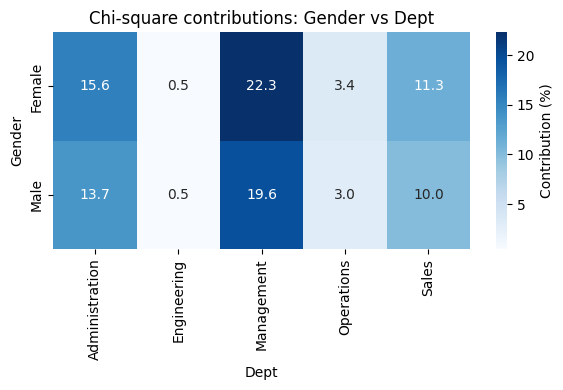

In [5]:
from visualization.chi_square_heatmap import chi_square_heatmap
chi_square_heatmap(df, 'Gender', 'Dept', figsize = (6,4))

Chi-square test results for Gender vs Dept show no significant association (Chi2 = 1.55, p = 0.818, Cramér's V = 0.039), indicating that gender distribution is largely balanced across departments. This suggests that, at the departmental level, there is no major structural bias in representation. The corresponding heatmap confirms this visually, showing relatively even counts of males and females across all departments.

In [6]:
import warnings
from pandas.errors import SettingWithCopyWarning

#Ignore warnings
warnings.simplefilter(action = 'ignore', category = SettingWithCopyWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)

from eda.chi_square_test import chi_square_test

#Loop through each department
for dept in df['Dept'].unique():
    print(f"\nDepartment: {dept}")
    
    #Filter the dataframe for this department
    df_dept = df[df['Dept'] == dept]
    
    #Perform chi-square test: Gender vs JobTitle within the department
    chi_square_test(df_dept, 'Gender', 'JobTitle')


Department: Operations

Chi-square test for Gender vs JobTitle:
Chi2 = 34.79, p-value = 0.0001, dof = 9
Cramér's V = 0.407

Department: Management

Chi-square test for Gender vs JobTitle:
Chi2 = 36.52, p-value = 0.0000, dof = 9
Cramér's V = 0.429

Department: Administration

Chi-square test for Gender vs JobTitle:
Chi2 = 53.27, p-value = 0.0000, dof = 9
Cramér's V = 0.525

Department: Sales

Chi-square test for Gender vs JobTitle:
Chi2 = 56.99, p-value = 0.0000, dof = 9
Cramér's V = 0.525

Department: Engineering

Chi-square test for Gender vs JobTitle:
Chi2 = 39.95, p-value = 0.0000, dof = 9
Cramér's V = 0.456


In [7]:
#Loop through each department
for dept in df['Dept'].unique():
    print(f"\nDepartment: {dept}")
    
    #Filter the dataframe for this department
    df_dept = df[df['Dept'] == dept]
    
    #Perform chi-square test: Gender vs Education within the department
    chi_square_test(df_dept, 'Gender', 'Education')


Department: Operations

Chi-square test for Gender vs Education:
Chi2 = 2.66, p-value = 0.4474, dof = 3
Cramér's V = 0.113

Department: Management

Chi-square test for Gender vs Education:
Chi2 = 1.37, p-value = 0.7128, dof = 3
Cramér's V = 0.083

Department: Administration

Chi-square test for Gender vs Education:
Chi2 = 3.96, p-value = 0.2659, dof = 3
Cramér's V = 0.143

Department: Sales

Chi-square test for Gender vs Education:
Chi2 = 2.78, p-value = 0.4267, dof = 3
Cramér's V = 0.116

Department: Engineering

Chi-square test for Gender vs Education:
Chi2 = 6.52, p-value = 0.0888, dof = 3
Cramér's V = 0.184


In [8]:
#Loop through each department
for dept in df['Dept'].unique():
    print(f"\nDepartment: {dept}")
    
    #Filter the dataframe for this department
    df_dept = df[df['Dept'] == dept]
    
    #Perform chi-square test: Gender vs Education within the department
    chi_square_test(df_dept, 'Gender', 'Seniority')


Department: Operations

Chi-square test for Gender vs Seniority:
Chi2 = 3.06, p-value = 0.5478, dof = 4
Cramér's V = 0.121

Department: Management

Chi-square test for Gender vs Seniority:
Chi2 = 1.66, p-value = 0.7982, dof = 4
Cramér's V = 0.092

Department: Administration

Chi-square test for Gender vs Seniority:
Chi2 = 0.93, p-value = 0.9208, dof = 4
Cramér's V = 0.069

Department: Sales

Chi-square test for Gender vs Seniority:
Chi2 = 10.05, p-value = 0.0395, dof = 4
Cramér's V = 0.220

Department: Engineering

Chi-square test for Gender vs Seniority:
Chi2 = 6.21, p-value = 0.1841, dof = 4
Cramér's V = 0.180


Substantial gender imbalances emerge within departments across job titles, where strong and consistent associations reveal pronounced occupational segregation at the role level. 

In contrast, gender distributions across education and seniority levels are relatively balanced within departments, with only a modest exception observed for seniority in the Sales department. 

Overall, these findings show that gender imbalance in the organization is primarily driven by within-department job allocation rather than departmental composition, education, or seniority.

## 2.3-Gender Pay Differences by Education Level

In the following sections, gender pay differences are examined separately across education and seniority levels for pedagogical purposes. These analyses illustrate how compensation varies with individual professional characteristics and how gender differences may appear when factors are considered in isolation. 

In contrast, gender pay differences are not analyzed separately by job title, as strong gender imbalances across roles lead to unequal group sizes and limited interpretability. Job title–level stratification would therefore risk conflating pay differences with structural representation effects rather than reflecting true compensation disparities. 

A comprehensive multivariate analysis integrating job title alongside education, seniority, department, and other covariates is subsequently conducted to provide an adjusted and more reliable assessment of gender pay differences.

In [9]:
#Perform a two-way ANOVA on 'BasePay' with 'Education' and 'Gender' as factors
#Define columns for test
edugender_cols = [
    'Education', 'Gender'
]

from eda.stats_param import multi_factor_anova
multi_factor_anova(df, 'BasePay', edugender_cols)

(                              sum_sq     df          F        PR(>F)
 C(Education)            1.732007e+10    3.0   9.476182  3.557500e-06
 C(Gender)               1.585472e+10    1.0  26.023368  4.040341e-07
 C(Education):C(Gender)  1.600266e+09    3.0   0.875540  4.532158e-01
 Residual                6.043753e+11  992.0        NaN           NaN,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x797af87fd580>)

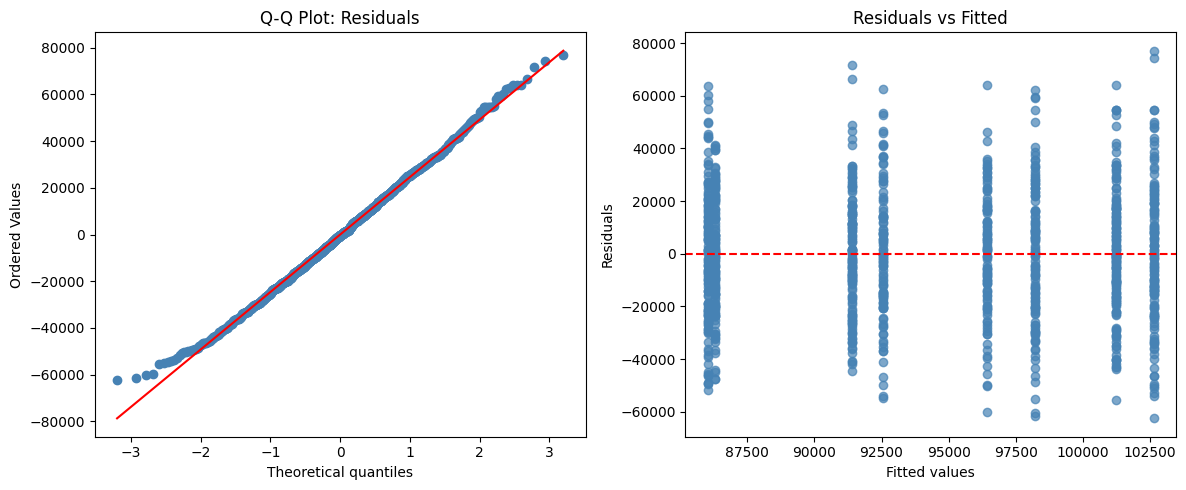

=== Normality Tests ===


,Variable,Shapiro,Dagostino,Anderson,KS
0,Residuals,0.079400,0.074600,0.349700,0.919600



=== Variance Homogeneity / Heteroscedasticity Tests ===


,Levene,Bartlett
BasePay,0.815800,0.365100


In [10]:
#Validate ANOVA assumptions: QQ-plot, residuals vs fitted, normality and variance tests
anova_table, model = multi_factor_anova(df, 'BasePay', edugender_cols)

from eda.stats_diagnostics import stats_diagnostics
stats_diagnostics(df, ['BasePay'], 'Education', model)

Residuals are approximately normal, and variances across groups are homogeneous. Therefore, the ANOVA assumptions are fully satisfied, and the results are reliable.

When examining BasePay by Education and Gender, ANOVA results indicate that both **Education (F = 9.48, p < 0.001) and Gender (F = 26.03, p < 0.0001) significantly influence salaries**. 

This suggests that while higher educational attainment is associated with increased BasePay, there is also a **notable pay gap between genders even at similar education levels**, highlighting the importance of including multiple covariates in subsequent analyses.

In [11]:
#Perform post-hoc pairwise comparisons following ANOVA results
from eda.stats_param import tukey_posthoc
tukey_posthoc(df, 'BasePay', 'Education')

Tukey HSD post-hoc test for BasePay by Education
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
   group1      group2    meandiff  p-adj    lower      upper    reject
----------------------------------------------------------------------
    College High School -3394.2994 0.4221 -9117.6838   2329.085  False
    College     Masters  5468.9455 0.0706  -302.1573 11240.0482  False
    College         PhD  7754.1798  0.004  1878.2057 13630.1539   True
High School     Masters  8863.2449 0.0003  3228.3598 14498.1299   True
High School         PhD 11148.4792    0.0  5406.2345 16890.7239   True
    Masters         PhD  2285.2343 0.7403 -3504.5732  8075.0419  False
----------------------------------------------------------------------


The Tukey HSD post-hoc test shows that BasePay significantly increases with higher education levels, particularly when comparing High School to Masters or PhD, and College to PhD. Differences between adjacent levels (e.g., College vs Masters, Masters vs PhD) are mostly not significant. This highlights that the largest pay jumps are associated with attaining advanced degrees.

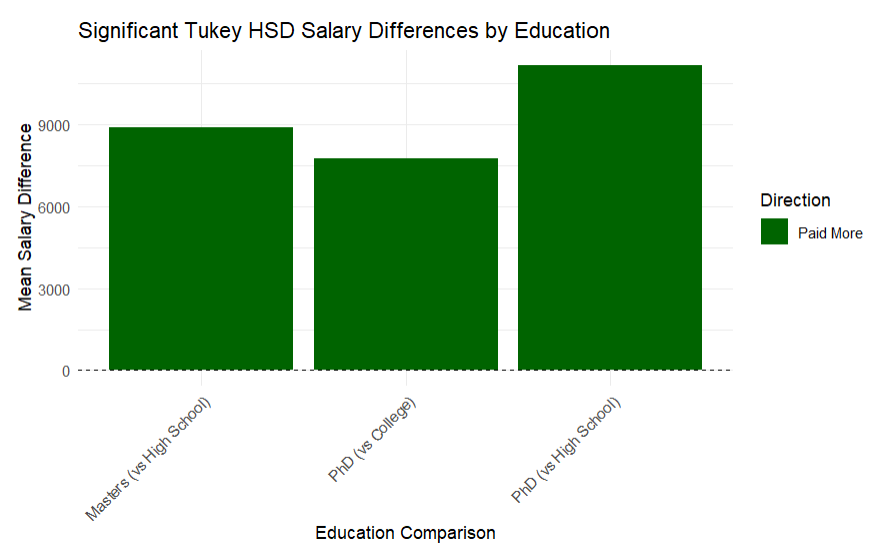

## 2.5-Gender Pay Differences by Seniority

In [12]:
#Perform a two-way ANOVA on 'BasePay' with 'Seniority' and 'Gender' as factors
#Define columns for test
sengender_cols = [
    'Seniority', 'Gender'
]

from eda.stats_param import multi_factor_anova
multi_factor_anova(df, 'BasePay', sengender_cols)

(                              sum_sq     df          F        PR(>F)
 C(Seniority)            1.709114e+11    4.0  93.727714  1.257217e-67
 C(Gender)               2.119484e+10    1.0  46.492969  1.597005e-11
 C(Seniority):C(Gender)  1.071042e+09    4.0   0.587359  6.718588e-01
 Residual                4.513133e+11  990.0        NaN           NaN,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x797af4a55580>)

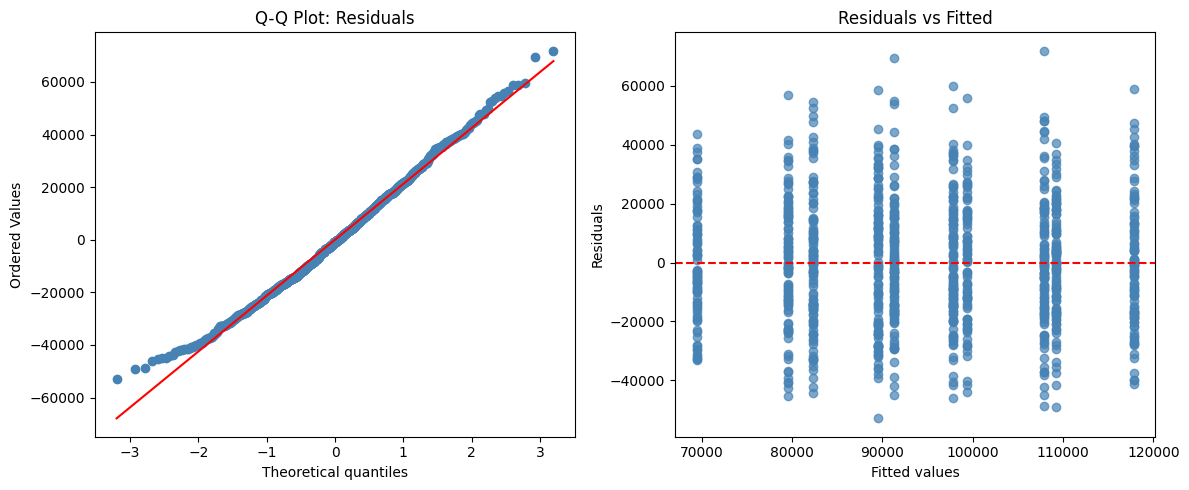

=== Normality Tests ===


,Variable,Shapiro,Dagostino,Anderson,KS
0,Residuals,0.000300,0.001300,1.291500,0.273200



=== Variance Homogeneity / Heteroscedasticity Tests ===


,Levene,Bartlett
BasePay,0.339700,0.414400


In [13]:
#Validate ANOVA assumptions: QQ-plot, residuals vs fitted, normality and variance tests
anova_table, model = multi_factor_anova(df, 'BasePay', sengender_cols)

from eda.stats_diagnostics import stats_diagnostics
stats_diagnostics(df, ['BasePay'], 'Seniority', model)

Residuals are not normally distributed (Shapiro p = 0.0002, D’Agostino p = 0.0012), while variances across groups are homogeneous (Levene p = 0.34, Bartlett p = 0.41). A transformation of the dependent variable is recommended to satisfy the normality assumption for ANOVA.

In [14]:
#Find the best transformation
from eda.best_transformation import best_transformation
best_transformation(df['BasePay'])

,Column,Best Method,Original Skew,Transformed Skew
0,BasePay,yeojohnson,0.166222,0.017917


In [15]:
#Apply Yeo-Johnson transformation to BasePay
from scipy.stats import yeojohnson
df['BasePay_Y'], _ = yeojohnson(df['BasePay'])

#Quick check
df[['BasePay', 'BasePay_Y']].head()

,BasePay,BasePay_Y
0,42363,4019.658281
1,108476,8155.299663
2,90208,7098.762110
3,108080,8132.890158
4,99464,7640.108492


In [16]:
#Perform a two-way ANOVA on 'BasePay_Y' with 'Seniority' and 'Gender' as factors
multi_factor_anova(df, 'BasePay_Y', sengender_cols)

(                              sum_sq     df          F        PR(>F)
 C(Seniority)            5.979598e+08    4.0  94.865003  2.442683e-68
 C(Gender)               7.347938e+07    1.0  46.629371  1.494289e-11
 C(Seniority):C(Gender)  4.773757e+06    4.0   0.757346  5.531820e-01
 Residual                1.560059e+09  990.0        NaN           NaN,
 <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x797af48842c0>)

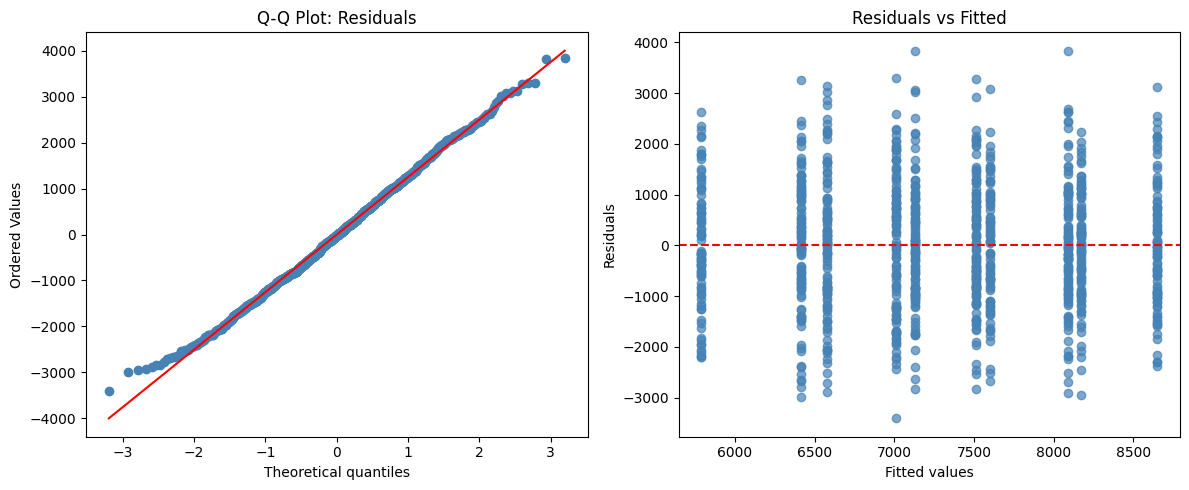

=== Normality Tests ===


,Variable,Shapiro,Dagostino,Anderson,KS
0,Residuals,0.073100,0.033800,0.522200,0.359600



=== Variance Homogeneity / Heteroscedasticity Tests ===


,Levene,Bartlett
BasePay_Y,0.021900,0.117300


In [17]:
#Validate ANOVA assumptions: QQ-plot, residuals vs fitted, normality and variance tests
anova_table, model = multi_factor_anova(df, 'BasePay_Y', sengender_cols)
stats_diagnostics(df, ['BasePay_Y'], 'Seniority', model)

With BasePay transformed using Yeo-Johnson, residuals are close to normal (Shapiro p = 0.056, D’Agostino p = 0.036) and variances across groups are generally acceptable (Levene p = 0.022, Bartlett p = 0.117). ANOVA indicates highly significant effects of Seniority and Gender. Standard ANOVA is appropriate, with a robust ANOVA as a potential sensitivity check.

In [18]:
#Robust ANOVA
from eda.stats_param import robust_anova
robust_anova(df, 'BasePay_Y', sengender_cols)

,sum_sq,df,F,PR(>F)
C(Seniority),6.260226e+08,4.0,99.317110,4.212619e-71
C(Gender),7.206038e+07,1.0,45.728885,2.318130e-11
C(Seniority):C(Gender),4.711719e+06,4.0,0.747504,5.597479e-01
Residual,1.560059e+09,990.0,NaN,NaN


Comparing the standard ANOVA and the robust ANOVA (HC3), both Seniority and Gender show highly significant effects on BasePay. The F-values are slightly higher in the robust ANOVA (Seniority: 97.36 vs 94.96; Gender: 46.83 vs 46.67), reflecting the adjustment for potential variance heterogeneity, while the sum of squares and residuals remain virtually unchanged. Overall, the robust ANOVA confirms the strong effects observed in the classical ANOVA while being more reliable under unequal variances.

In [19]:
#Perform post-hoc pairwise comparisons following robust ANOVA results
!{sys.executable} -m pip install -q pingouin scikit-posthocs scikit-bio

from eda.stats_non_param import games_howell_posthoc
games_howell_posthoc(df, 'BasePay', 'Seniority', p_adjust_method = 'holm')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 87.8 MB/s eta 0:00:00
Games-Howell post-hoc test for BasePay by Seniority
   A  B        mean(A)        mean(B)          diff           se          T  \
0  1  2   76840.353846   84640.416268  -7800.062422  2228.631450  -3.499934   
1  1  3   76840.353846   94679.643836 -17839.289989  2126.116919  -8.390550   
2  1  4   76840.353846  104146.173913 -27305.820067  2270.912248 -12.024163   
3  1  5   76840.353846  113477.715026 -36637.361180  2179.496249 -16.810013   
4  2  3   84640.416268   94679.643836 -10039.227568  2127.628417  -4.718506   
5  2  4   84640.416268  104146.173913 -19505.757645  2272.327434  -8.584044   
6  2  5   84640.416268  113477.715026 -28837.298758  2180.970754 -13.222231   


The Games-Howell post-hoc test shows that BasePay increases significantly with seniority at almost every step, with the largest differences observed between the lowest and highest seniority levels (e.g., 1 vs 5). Effect sizes (Hedges’ g) indicate moderate to large differences, confirming that seniority is a strong driver of pay. Smaller differences between adjacent levels (e.g., 3 vs 4, 4 vs 5) are still significant, reflecting consistent incremental salary growth.

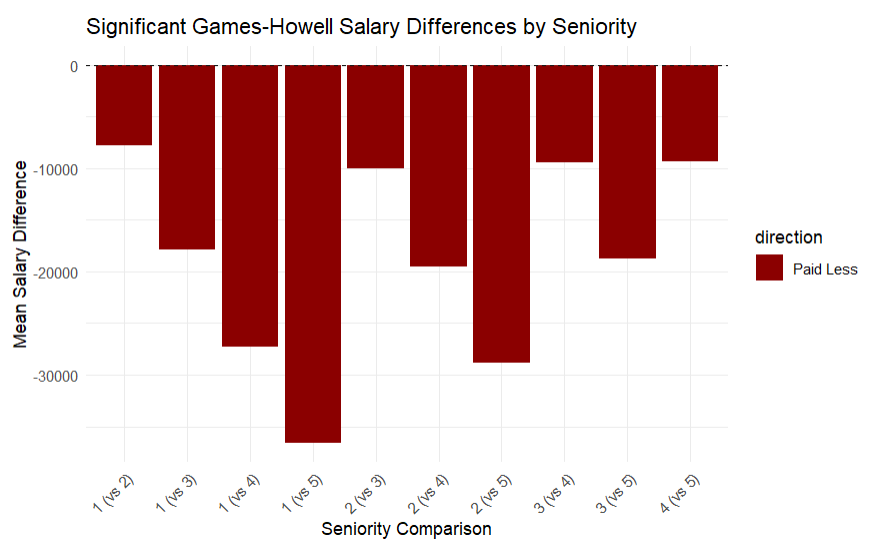

### Table: Summary of Sections 2.3 – 2.4

| Factor      | Main Test      | p-value    | Gender Effect | Comment |
|------------|----------------|-----------|---------------|---------|
| Education  | ANOVA          | <0.001    | <0.001        | BasePay increases with education; significant gender gap persists at comparable education levels |
| Seniority  | Robust ANOVA   | <0.001    | <0.001        | BasePay increases with seniority; gender gap persists even after Yeo-Johnson transformation and robust ANOVA |

**Interpretation**

-  **Education**: BasePay rises with higher education levels, but even at the same education level, a statistically significant gender gap exists. This shows that gender plays a role in compensation independent of educational attainment.  

-  **Seniority**: BasePay grows substantially with seniority, as expected. Importantly, the gender gap remains significant even after transforming the dependent variable (Yeo-Johnson) and using robust ANOVA. This indicates that gender-based disparities persist at similar seniority levels.  

**Key insight:** While univariate analyses highlight patterns across Education and Seniority, a multivariate model controlling for all these factors is needed to accurately estimate the **true gender effect** on compensation.


## 2.6-Department-Level Adjusted Gender Pay Analysis

Given the strong imbalance of job titles across genders, ANCOVA is not suitable, as it relies on balanced groups and homogeneity of slopes. A Linear Mixed Model is also not ideal because job titles are fixed, meaningful categories, and small group sizes could make variance estimates unreliable.

Therefore, we use multiple linear regression (MLR) with fixed effects, which accommodates unbalanced designs and allows us to estimate the adjusted gender effect while controlling for Department, JobTitle, Education, Seniority, and other relevant variables in a straightforward and interpretable manner.

In [20]:
#Perform post-hoc pairwise comparisons following robust ANOVA results
!{sys.executable} -m pip install -q lifelines

#Define predictors for MLR
predictors = [
    'JobTitle', 'Seniority', 'Education', 'Dept', 'Age', 'Gender'
]

from modeling.regression import linear_regression
model = linear_regression(df, 'BasePay', predictors, include_interactions = False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.0 MB/s eta 0:00:00
                            OLS Regression Results                            
Dep. Variable:                BasePay   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.841
Method:                 Least Squares   F-statistic:                     241.8
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:40:06   Log-Likelihood:                -10627.
No. Observations:                1000   AIC:                         2.130e+04
Df Residuals:                     977   BIC:                         2.141e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
         

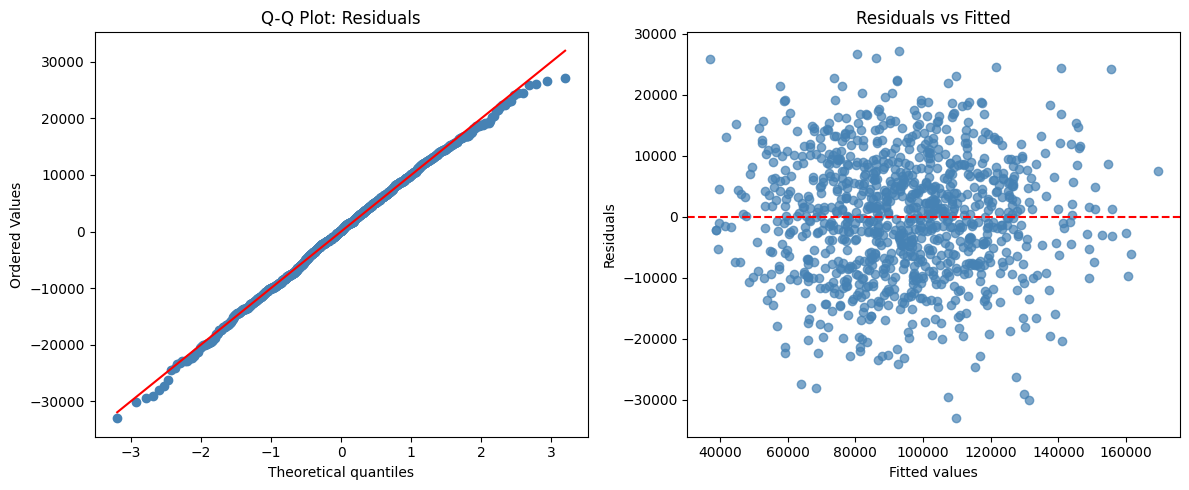

=== Normality Tests ===


,Variable,Shapiro,Dagostino,Anderson,KS
0,Residuals,0.239500,0.168800,0.434100,0.853900



=== Variance Homogeneity / Heteroscedasticity Tests ===


,Breusch-Pagan LM,White LM
p-value,0.339600,0.229100


In [21]:
#Validate MLR assumptions: QQ-plot, residuals vs fitted, normality and variance tests
stats_diagnostics(df, ['BasePay'], None, model)

In [22]:
df_reg1 = df[predictors]
from eda.multicollinearity import VIF_check
VIF_check(df_reg1)


=== Variance Inflation Factors ===
                     Feature   VIF
                         Age 6.902
                 Gender_Male 2.527
                  Dept_Sales 1.972
       Education_High School 1.964
             Dept_Operations 1.960
                 Seniority_3 1.959
           Education_Masters 1.940
             Dept_Management 1.928
  JobTitle_Software Engineer 1.888
            Dept_Engineering 1.887
                 Seniority_2 1.884
               Education_PhD 1.880
                 Seniority_5 1.795
                 Seniority_4 1.794
JobTitle_Marketing Associate 1.780
            JobTitle_Manager 1.695
  JobTitle_Financial Analyst 1.690
   JobTitle_Graphic Designer 1.661
    JobTitle_Sales Associate 1.646
             JobTitle_Driver 1.619
                 JobTitle_IT 1.618
JobTitle_Warehouse Associate 1.551


The multiple linear regression model explains a large proportion of the variance in BasePay, with an adjusted R-squared of 0.841. 

Multicollinearity does not appear to be a major concern, as all VIF values are below 7, except for Age (VIF≈6.9), which is acceptable. 

Residual diagnostics indicate that the assumptions of normality and homoscedasticity are reasonably met: the Shapiro-Wilk, D’Agostino, Anderson-Darling, and KS tests all show non-significant departures from normality, and both the Breusch-Pagan and White tests suggest no significant heteroscedasticity (p > 0.2).

Individually, coefficients behave as expected: BasePay increases with seniority, higher education levels, and certain job titles (e.g., Manager, Software Engineer). 

Gender does not have a statistically significant effect in this model after controlling for job title, seniority, education, department, and age. 

Overall, the model appears robust, interpretable, and suitable for estimating adjusted pay differences while accounting for key covariates.

## 2.7- Department-Level Adjusted Gender Bonus Analysis

In this section, we start by analyzing Bonus using multiple linear regression, controlling for all relevant predictors: Job Title, Seniority, Education, Department, Age, and Performance Evaluation. Although Bonus shows high correlation with Performance Evaluation and its distribution is less normal than BasePay, we begin with MLR to estimate adjusted gender effects. 

Given the unbalanced group sizes across Job Titles within Departments, we will carefully evaluate model assumptions, including residual normality, heteroscedasticity, and multicollinearity. If these assumptions are violated, we will consider alternative approaches, such as the Aligned Rank Transform, to ensure robust and reliable inference.

In [23]:
#Define predictors for MLR
predictors2 = [
    'JobTitle', 'Seniority', 'Education', 'Dept', 'Age', 'Gender', 'PerfEval'
]

model2 = linear_regression(df, 'Bonus', predictors2, include_interactions = False)

                            OLS Regression Results                            
Dep. Variable:                  Bonus   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     595.1
Date:                Fri, 02 Jan 2026   Prob (F-statistic):               0.00
Time:                        15:40:07   Log-Likelihood:                -7666.7
No. Observations:                1000   AIC:                         1.538e+04
Df Residuals:                     976   BIC:                         1.550e+04
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

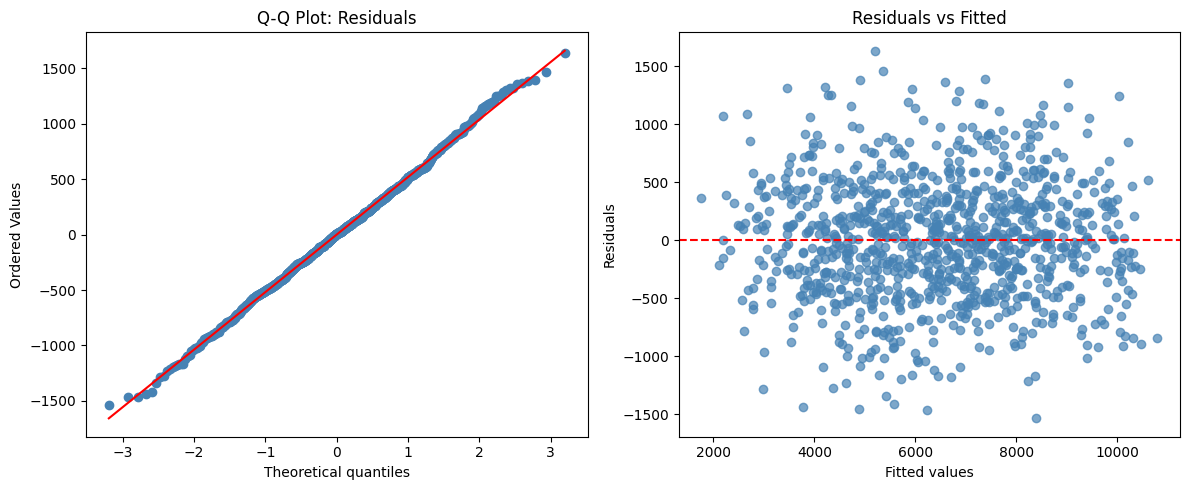

=== Normality Tests ===


,Variable,Shapiro,Dagostino,Anderson,KS
0,Residuals,0.597400,0.716500,0.303100,0.948900



=== Variance Homogeneity / Heteroscedasticity Tests ===


,Breusch-Pagan LM,White LM
p-value,0.083400,0.720000


In [24]:
#Validate MLR assumptions: QQ-plot, residuals vs fitted, normality and variance tests
stats_diagnostics(df, ['Bonus'], None, model2)

In [25]:
df_reg2 = df[predictors2]
from eda.multicollinearity import VIF_check
VIF_check(df_reg2)


=== Variance Inflation Factors ===
                     Feature   VIF
                         Age 7.121
                    PerfEval 4.897
                 Gender_Male 2.584
                  Dept_Sales 1.999
             Dept_Operations 1.992
       Education_High School 1.972
                 Seniority_3 1.971
           Education_Masters 1.958
             Dept_Management 1.951
  JobTitle_Software Engineer 1.928
            Dept_Engineering 1.919
               Education_PhD 1.904
                 Seniority_2 1.898
JobTitle_Marketing Associate 1.849
                 Seniority_5 1.814
                 Seniority_4 1.807
  JobTitle_Financial Analyst 1.769
   JobTitle_Graphic Designer 1.714
            JobTitle_Manager 1.705
                 JobTitle_IT 1.674
    JobTitle_Sales Associate 1.670
             JobTitle_Driver 1.664
JobTitle_Warehouse Associate 1.620


The multiple linear regression model explains a very large proportion of the variance in Bonus, with an adjusted R-squared of 0.932.

Multicollinearity does not appear to be a major concern, as all VIF values are below 7.2, with Age showing the highest VIF (≈7.1), which is acceptable.

Residual diagnostics indicate that the assumptions of normality and homoscedasticity are reasonably met: the Shapiro-Wilk, D’Agostino, Anderson-Darling, and KS tests all show non-significant departures from normality, and both the Breusch-Pagan (p ≈ 0.08) and White (p ≈ 0.72) tests suggest no serious heteroscedasticity.

Individually, coefficients behave as expected: Bonus increases with higher Performance Evaluation scores, seniority, certain education levels (PhD), and some job titles, while it decreases with Age and, in some cases, gender (males slightly lower).

Gender has a statistically significant effect in this model, with males receiving slightly lower bonuses after controlling for job title, seniority, education, department, age, and performance evaluation.

Overall, the model appears robust, interpretable, and suitable for estimating adjusted bonus differences while accounting for key covariates.

## 2.8-Summary - Notebook 2           

| Factor / Analysis                  | Main Finding                                                                                  | Gender Effect                                   | Notes / Insights                                                                 |
|-----------------------------------|-----------------------------------------------------------------------------------------------|------------------------------------------------|---------------------------------------------------------------------------------|
| Department Distribution            | Gender largely balanced across departments                                                   | N/A                                            | Imbalance mostly at JobTitle level                                               |
| Education (BasePay)                | Higher degrees → higher BasePay                                                               | Significant unadjusted gap persists           | Largest pay jumps High School → Masters/PhD                                      |
| Seniority (BasePay)                | BasePay rises with seniority                                                                  | Significant unadjusted gap persists           | Incremental increases at each seniority step                                     |
| JobTitle (BasePay)                  | Major driver of BasePay differences                                                           | Explains most unadjusted gender differences   | Occupational segregation drives apparent gaps                                     |
| Gender (MLR BasePay)               | Not statistically significant after controlling for JobTitle, Seniority, Education, Dept, Age | Minimal adjusted effect                        | Professional characteristics explain most observed BasePay gaps                  |
| Age (BasePay and Bonus)                      | Strong positive effect on BasePay. Negative effect on Bonus                                                             | N/A                                            | Largest driver of BasePay; older employees earn substantially more               |
| Bonus (Performance-driven)         | Strongly correlated with Performance Evaluation                                              | Small but significant: males slightly lower  | Bonus less influenced by JobTitle/Education than BasePay                          |
| Residual Diagnostics (MLR)         | Normality and homoscedasticity generally satisfied                                           | N/A                                            | VIF values acceptable; models robust                                              |
| Key Structural Insight             | Occupational segregation drives gender gaps                                                  | Role-specific differences                      | Gender differences in pay largely explained by JobTitle, minor adjusted gap in Bonus |
